# Introduction

## Goal

Apply OGSE spot mask for camera tests:

- Inject four point sources and one circular extended source, following the description of the OGSE spot mask for camera tests (**PLATO-DLR-PL-TN-0069**);
- The **projection ratio** (from holes in the OGSE spot mask to spots on the CCD) is **5:1**;
- In absence of a PSF, all **illuminated pixels** should receive the **same flux**.

The manufacturing drawing of the OGSE spot mask, as taken from PLATO-DLR-PL-TN-0069 is shown in the figure below (coordinates are in mm):

<img src="mask.png" width=500>

Remarks:

- The circular extended source is approximated by placing (faint) point sources in every sub-pixels illuminated through the big hole in the mask;
- The script takes the magnitude of the point sources as input for now (as this is what PlatoSim uses as input in the star catalogue);
- As the mask can be rotated in the OGSE, the orientation angle of the mask reference frame w.r.t. the focal-plane reference frame should be given;
- The simulation will be repeated with the same settings but without the sources.

## Starting Conditions

Before you can start, you have to do a couple of imports and create a `Simulation` object.  You will use that to configure and run the simulations.

**Imports**

In [1]:
from simulation import Simulation
from simfile import SimFile
import os
from math import radians, sin, cos, tan, floor, ceil
import numpy as np
import referenceFrames as rf
from SpotMask import insert_ogse_spot_mask
from hdf5ToFits import hdf5ToFits
from astropy.io import fits

**Create a `Simulation` object with an arbitrary name**

Here the arbitrary name is "ogse-spot-mask".

In [2]:
simulation_name = "ogse-spot-mask"
sim = Simulation(simulation_name)

**Specify the folder where the output files should be stored**

All output files will have the same name (here: "ogse-spot-mask") but different extensions (hdf5, log, and yaml).

In [3]:
sim.outputDir = os.environ["PLATO_WORKDIR"]

## Settings

This section contains the settings you will want to play with.  The actual configuration of these settings in the `Simulation` object will be done in the section "Configuring the Settings".

**(1) Field angles (θ, φ) at which you want to project the centre of the mask**
* θ [degrees]: angular distance from the optical axis;
* φ [degrees]: in-field angle, measured in the counter-clockwise direction, from the x-axis of the focal-plane reference frame.

In [4]:
mask_center_theta = 2
mask_center_phi = 30

**(2) Rotation angle of the mask reference frame w.r.t. the focal-plane reference frame**

The angle between the (projected) mask reference frame w.r.t. the focal-plane reference plane [degrees].

In [5]:
rotation_angle_mask_fp = 0

**(3) Magnitude of the point sources**

In [6]:
magnitude_point_source = 10

The magnitude of the faint point sources making up the extended source will be scaled to ensure that - in absence of a PSF - all illuminated pixels receive the same flux.

**(4) Background**

It will probably not be perfectly dark in the test environment, so we must account for the  contribution of the background [photons/pixel/s].

In [7]:
background = 0

**(5) Readout mode**

- Nominal-readout mode: the whole image area of the CCD will be read out;
- Partial-readout mode: only the specified rows of the image area of the CCD will be read out.

In [8]:
# Should either be "Nominal" or "Partial"

readout_mode = "Partial"

In case of partial-readout noise, you also have to specify what the first row of the CCD is you want to read out (counting starts at zero) and how many rows you want to read out. All other rows are dumped.

In [9]:
first_row_readout = 0     # [0, 4510[
num_rows_readout = 4510   # [1, 4510]

**(6) Exposure time**

PlatoSim takes the image cycle time as input, which is the sum of the exposure time and the readout time before the next exposure starts.  For normal camera, the latter will be the total readout time; for fast cameras this will be the frame transfer time.

Specify the exposure time [s].

In [10]:
exposure_time = 21

**(7) Number of exposures**

In [11]:
num_exposures = 10

**(8) Dimensions of the sub-field**

In [12]:
num_rows_subfield = 100
num_columns_subfield = 100

# Configuration

## Freely Changeable Configuration Parameters

This section describes how you can enable/disable features in PlatoSim, without compomising the settings from above.  

You are free to tweak the parameters in this section.

**"Sky" properties**

In [13]:
# Specify whether or not you want to include cosmic hits

sim["Sky/IncludeCosmicsInSubField"] = "no"

**Platform properties**

In [14]:
# Don't include jitter

sim["Platform/UseJitter"] = "no"

**Telescope properties**

In [15]:
# Specify which telescope group you are using
# (can be 1/2/3/4/"Fast")

sim["Telescope/GroupID"] = 1

# Don't include drift

sim["Telescope/UseDrift"] = "no"

**Camera properties**

In [16]:
# Disable aberration correction

sim["Camera/IncludeAberrationCorrection"] = "no"

# Specify whether or not you want to include field distortion

sim["Camera/IncludeFieldDistortion"] = "no"

**PSF properties**

In [17]:
# Specify the type of PSF you want to use
# Options are: "MappedFromFileAsymmetrical", "MappedFromFileSymmetrical", "Mapped Gaussian", and "AnalyticNonGaussian"

sim["PSF/Model"] = "MappedFromFileAsymmetrical"

**FEE properties**

**CCD properties**

In [18]:
# Specify which effects you want to include in the simulation

sim["CCD/IncludeFlatfield"] = "yes"
sim["CCD/IncludeDarkSignal"] = "yes"
sim["CCD/IncludeBFE"] = "yes"
sim["CCD/IncludePhotonNoise"] = "yes"
sim["CCD/IncludeReadoutNoise"] = "yes"
sim["CCD/IncludeCTIeffects"] = "yes"
sim["CCD/IncludeChargeInjection"] = "no"
sim["CCD/IncludeOpenShutterSmearing"] = "yes"
sim["CCD/IncludeQuantumEfficiency"] = "yes"
sim["CCD/IncludeRelativeTransmissivity"] = "yes"
sim["CCD/IncludePolarization"] = "yes"
sim["CCD/IncludeParticulateContamination"] = "yes"
sim["CCD/IncludeMolecularContamination"] = "yes"
sim["CCD/IncludeConvolution"] = "yes"
sim["CCD/IncludeFullWellSaturation"] = "yes"
sim["CCD/IncludeDigitalSaturation"] = "yes"
sim["CCD/IncludeQuantisation"] = "yes"

**Sub-field properties**

In [19]:
# Specify the sub-pixel resolution

sim["SubField/SubPixels"] = 8

## Configuring the Settings

In this section, the actual configuration of the settings from above is done in the `Simulation` object.

<span style="color:red">Do not change anything to this section!</span>

**Number of exposures**

In [20]:
sim["ObservingParameters/NumExposures"] = num_exposures

**Background contribution**

In [21]:
sim["Sky/SkyBackground"] = background

**Readout mode**

In [22]:
sim["CCD/ReadoutMode/ReadoutMode"] = readout_mode

In [23]:
if sim["CCD/ReadoutMode/ReadoutMode"] == "Partial":
    
    sim["CCD/ReadoutMode/Partial/FirstRowReadout"] = first_row_readout
    sim["CCD/ReadoutMode/Partial/NumRowsReadout"] = num_rows_readout

**Image cycle time**

The image cycle time will be calculated automatically, based on the exposure time and the readout properties you have specified above.

In [24]:
readout_time_before_next,readout_time_during_next = sim.getReadoutTime()

sim["ObservingParameters/CycleTime"] = exposure_time + readout_time_before_next

**Sub-field**

Determine on which CCD the (centre  of the) mask will be projected and calculate the pixel coordinates of the projected mask centre on this CCD.

In [25]:
if (mask_center_phi // 90) > 0:
    
    ccd_code = str(mask_center_theta % 90)

else:
    
    ccd_code = "4"

Convert the field angles to pixel coordinates (i.e. in the CCD reference frame).

In [26]:
theta_radians = radians(mask_center_theta)
phi_radians = radians(mask_center_phi)
focal_length = sim["Camera/FocalLength/ConstantValue"] * 1000 # [mm]
pixel_size = sim["CCD/PixelSize"]

column, row = rf.focalPlaneAngles2pixelCoordinates(theta_radians, phi_radians, ccd_code, pixel_size, focal_length)

Position the centre of the sub-field at the projected mask centre.  This will automatically set the CCD code and the properties of the sub-field (i.e. zeropoint).

In [27]:
sim.setSubfieldAroundPixelCoordinates(ccd_code, column, row, num_columns_subfield, num_rows_subfield)

In [28]:
print(f"The centre of the projected mask will fall on CCD {ccd_code} at pixel (row, column) = ({int(row)}, {int(column)}).")

The centre of the projected mask will fall on CCD 4 at pixel (row, column) = (4166, 167).


If you are using partial-readout mode, you'd better check whether the sub-field is (entirely) located in the region of the image area that will be read out.

In [29]:
if readout_mode == "Partial":
    
    if first_row_readout > row - num_rows_subfield / 2:
        
        print(f"The lower edge of the sub-field is in row {floor(row - num_rows_subfield / 2)}, whereas the first row that will be read out is row {first_row_readout}")
        
    if first_row_readout + num_rows_readout < row + num_rows_subfield / 2:

        print(f"The upper edge of the sub-field is in row {ceil(row + num_rows_subfield / 2)}, whereas the first row that will be read out is row {first_row_readout + num_rows_readout}")

Check whether the projected mask entirely fits on the CCD.

In [30]:
if row - num_rows_subfield / 2 < 0:
    
    print(f"The sub-field falls off the CCD on the lower edge.")
    
if row + num_rows_subfield / 2 > sim["CCD/NumRows"]:
    
    print(f"The sub-field falls off the CCD on the upper edge.")
    
if column - num_columns_subfield / 2 < 0:
    
    print(f"The sub-field falls off the CCD on the left edge.")
    
if column + num_columns_subfield / 2 > sim["CCD/NumColumns"]:
    
    print(f"The sub-field falls off the CCD on the right edge.")    

# Insert the OGSE Spot Mask

At the top of this notebook, the rotation angle of the mask reference frame was given w.r.t. the focal-plane reference frame, but we actually need it w.r.t. the CCD reference frame when calling `insert_ogse_spot_mask`.

In [31]:
# Orientation angle of the CCD reference frame w.r.t. the focal-plane reference frame [degrees]

ccd_orientation = sim["CCDPositions/Orientation"][int(ccd_code) - 1]

# Rotation angle of the mask reference frame w.r.t. the CCD reference frame [degrees]

rotation_angle_mask_ccd = rotation_angle_mask_fp - ccd_orientation

Insert the OGSE spot mask into the simulation.

In [32]:
insert_ogse_spot_mask(sim, magnitude_point_source, rotation_angle_mask=rotation_angle_mask_ccd)

<span style="color:red">This concludes the configuration of the settings.</span>

# Execute the Simulation

Execute the simulation.  Any existing files will be over-written.

In [33]:
sim_file = sim.run(removeOutputFile=True)

print(f"Output stored in {sim.outputDir}:\n")

print(f"\t* {simulation_name}.hdf5: the simulated data;")
print(f"\t* {simulation_name}.log: the log file;")
print(f"\t* {simulation_name}.yaml: configuration file with all configuration parameters.")



Output stored in /Users/sara/work/Instrumentation/Plato/workdir/:

	* ogse-spot-mask.hdf5: the simulated data;
	* ogse-spot-mask.log: the log file;
	* ogse-spot-mask.yaml: configuration file with all configuration parameters.


# Repeat without OGSE Source Mask

When executing this simulations, you will probably see warning messages informating like these (unless you have changed the logging level):

```
WARNING Simulation: no information about detected stars to write to HDF5
WARNING Camera: No star positions to write to HDF5 file.
```

That is a good sign, because we are simulating a sub-field without spots.

In [34]:
sim.runName = sim.runName +"-without-spots"

# Make an empty star catalogue

star_catalog_filename = sim.outputDir + "empty.txt"
np.savetxt(star_catalog_filename, np.transpose([[], [], []]), fmt=['%11.6f', '%11.6f', '%8.4f'])
sim["ObservingParameters/StarCatalogFile"] = star_catalog_filename

# Change the seeds

sim["RandomSeeds/ReadOutNoiseSeed"] = sim["RandomSeeds/ReadOutNoiseSeed"] + 1
sim["RandomSeeds/PhotonNoiseSeed"] = sim["RandomSeeds/PhotonNoiseSeed"] + 1
sim["RandomSeeds/JitterSeed"] = sim["RandomSeeds/JitterSeed"] + 1
sim["RandomSeeds/FlatFieldSeed"] = sim["RandomSeeds/FlatFieldSeed"] + 1
sim["RandomSeeds/DriftSeed"] = sim["RandomSeeds/DriftSeed"] + 1
sim["RandomSeeds/CosmicSeed"] = sim["RandomSeeds/CosmicSeed"] + 1
sim["RandomSeeds/DarkSignalSeed"] = sim["RandomSeeds/DarkSignalSeed"] + 1

sim_file_no_spots = sim.run(removeOutputFile=True)

print(f"Output stored in {sim.outputDir}:\n")

print(f"\t* {simulation_name}-without-spots.hdf5: the simulated data;")
print(f"\t* {simulation_name}-without-spots.log: the log file;")
print(f"\t* {simulation_name}-without-spots.yaml: configuration file with all configuration parameters.")


2020-10-27 14:50:18 WARNING Simulation: no information about detected stars to write to HDF5
2020-10-27 14:50:18 WARNING Camera: No star positions to write to HDF5 file.

Output stored in /Users/sara/work/Instrumentation/Plato/workdir/:

	* ogse-spot-mask-without-spots.hdf5: the simulated data;
	* ogse-spot-mask-without-spots.log: the log file;
	* ogse-spot-mask-without-spots.yaml: configuration file with all configuration parameters.


# Image Inspection

Choose here which exposure you are interested in (counting starts at zero).

In [35]:
exposure = 0

## Visualisation

**With the OGSE spot mask**

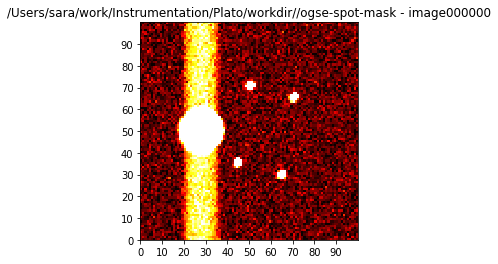

In [36]:
sim_file.showImage(exposure)

**Without the spots**

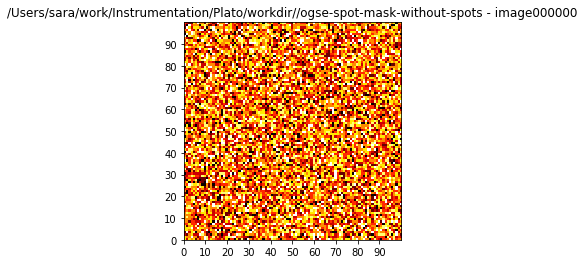

In [37]:
sim_file_no_spots.showImage(0)

## Extract images

The exposures can be extracted into a numpy array.

**With the OGSE spot mask**

In [38]:
image = sim_file.getImage(0)

print(image)

[[1002 1000 1001 ...  999 1002 1000]
 [1002 1004 1002 ... 1005 1000 1003]
 [1002 1001 1001 ... 1000  998 1003]
 ...
 [1001 1002 1002 ... 1001 1005 1001]
 [ 998 1003 1001 ...  999 1001  999]
 [ 999  999 1002 ...  999 1000 1002]]


**Without the spots**

In [39]:
image_no_spots = sim_file_no_spots.getImage(0)

print(image_no_spots)

[[1002  999 1002 ... 1000 1001 1001]
 [1002 1001 1001 ...  999 1000  999]
 [ 999  998 1001 ... 1004 1001  998]
 ...
 [ 998 1004 1002 ... 1002  999  999]
 [ 999  996 1004 ... 1003  999 1000]
 [1000  999  998 ...  997 1001 1001]]


# Conversion from HDF5 to FITS

Convert the output HDF5 file to a FITS file with the same name, stored in the same directory.

Should the output HDF file already exist, the conversion will fail.

**With the OGSE spot mask**

In [40]:
input_filename = sim.outputDir + simulation_name + ".hdf5"
output_filename = sim.outputDir + simulation_name + ".fits"

# Convert the output HDF5 file to a FITS file with the same name,
# stored in the same directory

try:
    
    hdf5ToFits(input_filename, output_filename)
    
    print(f"Converted {input_filename} \nto {output_filename}.")
    
except OSError:
    
    print(f"\nFile {output_filename} already exists.\nPlease, (re)move it before you try converting the HDF5 file to FITS.")

Converted /Users/sara/work/Instrumentation/Plato/workdir/ogse-spot-mask.hdf5 
to /Users/sara/work/Instrumentation/Plato/workdir/ogse-spot-mask.fits.


**Without the spots**

In [41]:
input_filename = sim.outputDir + simulation_name + "-without-spots.hdf5"
output_filename = sim.outputDir + simulation_name + "-without-spots.fits"

# Convert the output HDF5 file to a FITS file with the same name,
# stored in the same directory

try:
    
    hdf5ToFits(input_filename, output_filename)
    
    print(f"Converted {input_filename} \nto {output_filename}.")
    
except OSError:
    
    print(f"\nFile {output_filename} already exists.\nPlease, (re)move it before you try converting the HDF5 file to FITS.")

Converted /Users/sara/work/Instrumentation/Plato/workdir/ogse-spot-mask-without-spots.hdf5 
to /Users/sara/work/Instrumentation/Plato/workdir/ogse-spot-mask-without-spots.fits.


# Read the files back in

In this section we describe how the HDF5 and FITS files can be read back in.

Choose here whether you want to see it demonstrated on the output of the simulations with or without the OGSE spot mask.

In [42]:
with_spot_mask = True

Choose here which exposure you are interested in (counting starts at zero).

In [43]:
exposure = 0

## HDF5

You can read the HDF5 files back into a `SimFile` object, and apply the same methods to it as before to extract and visualise individual exposures.  You can also have a look at the tutorial `InspectHDF5` (also under `/docs/tutorials`).

Alternatively, you can load the HDF5 files into designated applications, such as [HDFCompass](https://portal.hdfgroup.org/display/support).

**Determine the filename**

In [44]:
if with_spot_mask:
    
    filename = sim.outputDir + simulation_name + ".hdf5"
    
else:
    
    filename = sim.outputDir + simulation_name + "-without-spots.hdf5"

**Read the HDF5 file into a `SimFile` object**

In [45]:
sim_file_read_in = SimFile(filename)

**Apply the methods as demonstrated before**

In [46]:
image_read_in_hdf5 = sim_file_read_in.getImage(exposure)

print(image_read_in_hdf5)

[[1002 1000 1001 ...  999 1002 1000]
 [1002 1004 1002 ... 1005 1000 1003]
 [1002 1001 1001 ... 1000  998 1003]
 ...
 [1001 1002 1002 ... 1001 1005 1001]
 [ 998 1003 1001 ...  999 1001  999]
 [ 999  999 1002 ...  999 1000 1002]]


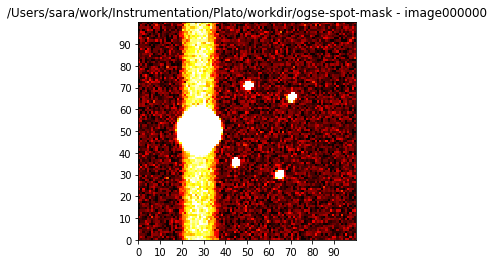

In [47]:
sim_file_read_in.showImage(exposure)

## FITS

**Determine the filename**

In [48]:
if with_spot_mask:
    
    filename = sim.outputDir + simulation_name + ".fits"
    
else:
    
    filename = sim.outputDir + simulation_name + "-without-spots.fits"

**Open the FITS file**

In [49]:
hdul = fits.open(sim.outputDir + simulation_name + ".fits")

**Get an overview of the information that is included in the FITS file**

In [50]:
hdul.info()

Filename: /Users/sara/work/Instrumentation/Plato/workdir/ogse-spot-mask.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   ()      
  1  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
  2  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
  3  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
  4  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
  5  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
  6  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
  7  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
  8  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
  9  WINDOW1       1 ImageHDU        28   (100, 100)   int16 (rescales to uint16)   
 10  WINDOW1       1 ImageHDU        28   (10

You will see that there are two extensions:
* `PRIMARY`: This is the primary header and contains only the header information but no image data;
* `WINDOW1`: Since all exposures map the exact same sub-field, they will all end up under the same extension.

**Primary HDU**

The header information of the primary header can be inspected as follows:

In [51]:
hdul[0].header

SIMPLE  = 'T       '                                                            
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
FOCALLEN=               247.52 / Focal length [mm]                              
NWINDOWS=                    1 / Number of windows                              
DATE-OBS= '2020-10-27 14:50:18'                                                 

Specific for the performed simulation are:
* `FOCALLEN`: The  focal length [mm];
* `NWINDOWS`: The number of windows (1, since all exposures simulate exactly the same sub-field).

**Extract all information for a given exposure**

In [52]:
extension_slice = hdul[exposure + 1]

**Image header**

The header information of this exposure can be inspected as follows:

In [53]:
header = extension_slice.header

header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                   16 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  100                                                  
NAXIS2  =                  100                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
BSCALE  =                    1                                                  
BZERO   =                32768                                                  
FOCALLEN=               247.52 / Focal length [mm]                              
CTYPE1  = 'LINEAR  '           / Linear coordinate transformation               
CTYPE2  = 'LINEAR  '           / Linear coordinate transformation               
CUNIT1  = 'MM      '        

Specific for the performed simulation are:
* `NAXIS1`: The number of columns in the sub-field [pixels];
* `NAXIS2`: The number of rows in the sub-field [pixels];
* `FOCALLEN`: The  focal length [mm];
* `CUNIT1` and `CUNIT2`: The unit of the focal-plane coordinates (i.e. in which the pixel size is specified);
* `CDELT1` and `CDELT2`: The pixel size [mm];
* `CRPIX1`: The column coordinate of the CCD origin in the sub-field reference frame [pixels];
* `CRPIX2`: The row coordinate of the CCD origin in the sub-field reference frame [pixels];
* `CCD_ID`: The CCD code;
* `CRVAL1`: The x-coordinate of the CCD origin in the focal-plane reference frame [mm];
* `CRVAL2`: The y-coordinate of the CCD origin in the focal-plane reference frame [mm];
* `CROTA2`: The CCD orientation angle w.r.t. the focal-plane reference frame [degrees];
* `EXTNAME`: Since all exposures simulate exactly the same sub-field, the extension name will be `WINDOW1` for all of them.

The values for the `CD` keywords are determined from the `CDELT` and `CROTA2` keywords.

To extract the value of a keyword (e.g. `CCD_ID`), you have to do:

In [54]:
keyword = "CCD_ID"

print(extension_slice.header[keyword])

4


**Image data**

Extracting the image data for this exposure into a numpy array can be done as follows:

In [55]:
image_read_in_fits = extension_slice.data

print(image_read_in_fits)

[[1002 1000 1001 ...  999 1002 1000]
 [1002 1004 1002 ... 1005 1000 1003]
 [1002 1001 1001 ... 1000  998 1003]
 ...
 [1001 1002 1002 ... 1001 1005 1001]
 [ 998 1003 1001 ...  999 1001  999]
 [ 999  999 1002 ...  999 1000 1002]]


Don't forget to close the FITS file again.

In [56]:
hdul.close()